# Chest X-ray encoder — DenseNet121 (variant 1: single processed view)

Trains a DenseNet121 on MIMIC-CXR radiographs to predict in-hospital mortality and exports the
image embeddings that the fusion notebooks in this directory consume.

**Image preprocessing.** Grayscale → aspect-preserving resize to 224 on the long side, padded to
square → bilateral filter (d=9) → gamma correction (γ=1.2) → CLAHE (clip 2.0, 8×8 tiles). The
single processed image is replicated across all three input channels.

**Outputs**
- `../Data/Representations/CXR/cxr_densnet_representation.csv` — per-image embeddings
- `./Results/CXR_Max_Result.csv` — per-patient predictions
- `./checkpoints/CNN_DenseNet_1/` — model checkpoints

Compare with `02. Chest Xrays (DenseNet 2).ipynb`, which builds the three channels from three
different views of the radiograph instead.

> Displayed radiographs and Grad-CAM overlays have been removed from this notebook's stored
> outputs to comply with the PhysioNet Credentialed Health Data Use Agreement. Re-running the
> notebook against your own copy of MIMIC-CXR regenerates them.

### Import

In [1]:
import os
import gc
import cv2
import copy
import pickle 
import itertools
import skimage.io
import numpy as np
import pandas as pd
import datetime as dt
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from plot_metric.functions import BinaryClassification

from aequitas.bias import Bias
from aequitas.group import Group
from aequitas.plotting import Plot
from aequitas.fairness import Fairness

import albumentations
from datasets import Image
from datasets import Dataset as hugging_dataset

import torch
import torch.nn as nn
import torchvision.models as models
import torchxrayvision as xrv
import torch.nn.functional as F
from torch.autograd import Function
from torch.utils.data import Dataset as torch_dataset
from torch.utils.data import DataLoader

from torchvision import models
import torchvision.transforms as transforms

from PIL import Image as PILImage

from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression

from torch.optim import AdamW

from transformers import get_scheduler
from transformers import get_linear_schedule_with_warmup

from timm.scheduler.scheduler import Scheduler
from timm.scheduler.cosine_lr import CosineLRScheduler
from timm.scheduler.step_lr import StepLRScheduler

from timm.data import Mixup
from timm.data import create_transform
from timm.data.transforms import str_to_pil_interp

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.image import deprocess_image
from pytorch_grad_cam.utils.image import preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

pd.options.display.max_rows = 1000
pd.options.display.max_colwidth = 10000
pd.set_option('display.max_columns', 500)

### General Path

In [2]:
mimiciv    = "PATH TO DATA/mimiciv(2.2)/"
race_path  = "Extraction/MIMICIV/Data/csvExtract/"
path_data  = "../Data/EHR/"
path_cohort= "../Data/Cohorts/"
path_out   = "../Data/Representations/CXR/"

### Read Cohorts Splits

In [3]:
with open(path_cohort + "short_icustays", "rb") as fp:   
    short_icustays = pickle.load(fp)
    
with open(path_cohort + "train_icustays", "rb") as fp:   
    train_icustays = pickle.load(fp)
    
with open(path_cohort + "valid_icustays", "rb") as fp:   
    valid_icustays = pickle.load(fp)
    
with open(path_cohort + "test_icustays" , "rb") as fp:   
    test_icustays = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_text_image", "rb") as fp:   
    icustays_ehr_text_image = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_text", "rb") as fp:   
    icustays_ehr_text = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_only", "rb") as fp:   
    icustays_ehr_only = pickle.load(fp)
    
with open(path_cohort + "note_ids_24h", "rb") as fp:   
    note_ids_24h = pickle.load(fp)
    
with open(path_cohort + "image_ids_24h", "rb") as fp:   
    image_ids_24h = pickle.load(fp)

### Read Data

In [4]:
all_cxr_ids = pd.read_csv(path_data + 'all_cxr_ids.csv', low_memory=False, index_col=False)
all_cxr_ids = all_cxr_ids[all_cxr_ids.cxr_image.notnull()]
all_cxr_ids.head(2)

In [5]:
print(all_cxr_ids.stay_id.nunique())
print(all_cxr_ids.shape)

14219
(50336, 10)


### Spliting Train - Validation - Test

In [6]:
label = 'icu_expire_flag'

In [7]:
train_df = all_cxr_ids[all_cxr_ids.stay_id.isin(train_icustays)]
valid_df = all_cxr_ids[all_cxr_ids.stay_id.isin(valid_icustays)]
test_df  = all_cxr_ids[all_cxr_ids.stay_id.isin(test_icustays)]

train_df.sort_values(by=['stay_id', 'Bins'], inplace=True)
valid_df.sort_values(by=['stay_id', 'Bins'], inplace=True)
test_df.sort_values( by=['stay_id', 'Bins'], inplace=True)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [9]:
del all_cxr_ids
gc.collect()

36

### Prepare Test Result Frame

In [10]:
def result_frame(data, label):
        
    result = data.groupby(['stay_id'])[['stay_id', 'gender', 'age', 'race', label]].head(1).copy()
    
    result['ICU_FLAG'] = np.nan
    result.loc[result['icu_expire_flag'] == 0, 'ICU_FLAG'] = 'Survived'
    result.loc[result['icu_expire_flag'] == 1, 'ICU_FLAG'] = 'Dead'
    
    return result

In [11]:
train_result = result_frame(train_df, label)
valid_result = result_frame(valid_df, label)
test_result  = result_frame(test_df , label)

train_result = train_result.reset_index(drop=True)
valid_result = valid_result.reset_index(drop=True)
test_result  = test_result.reset_index(drop=True)

### Select columns

In [14]:
train_df = train_df[['stay_id', 'icu_expire_flag', 'cxr_image']]
valid_df = valid_df[['stay_id', 'icu_expire_flag', 'cxr_image']]
test_df  = test_df[[ 'stay_id', 'icu_expire_flag', 'cxr_image']]

train_df = train_df[train_df.cxr_image.notnull()]
valid_df = valid_df[valid_df.cxr_image.notnull()]
test_df  = test_df[test_df.cxr_image.notnull()]

train_df.head(3)

### Read CXR Path Files

In [15]:
cxrrecord = pd.read_csv(mimiciv + "cxr/cxr-record-list.csv")
cxrmetadata = pd.read_csv(mimiciv + "cxr/mimic-cxr-2.0.0-metadata.csv")
cxr_record  = pd.merge(cxrmetadata, cxrrecord, on=['dicom_id', 'subject_id', 'study_id'], how='left')

In [16]:
cxr_record['StudyDate'] = pd.to_datetime(cxr_record['StudyDate'], format='%Y%m%d')
cxr_record['StudyTime'] = cxr_record.apply(lambda x : '%#010.3f' % x['StudyTime'] ,1)
cxr_record['StudyTime'] = pd.to_datetime(cxr_record['StudyTime'], format='%H%M%S.%f').dt.time
cxr_record['cxrtime']   = cxr_record.apply(lambda r : dt.datetime.combine(r['StudyDate'],r['StudyTime']),1)
cxr_record['cxrtime']   = cxr_record['cxrtime'].dt.floor('Min')

In [17]:
prefix_cxr_path = 'PATH TO DATA/mimiciv(2.2)/cxr/image/'
cxr_record['path'] = cxr_record['path'].map(lambda x: x.replace('.dcm', '.jpg'))
cxr_record['path'] = cxr_record['path'].map(lambda x: x.replace('files/', prefix_cxr_path))
cxr_record.rename(columns={"dicom_id": "cxr_image"}, inplace=True)
cxr_record = cxr_record[cxr_record.ViewPosition.isin(["AP", "PA"])]

In [18]:
cxr_record = cxr_record[['subject_id', 'study_id', 'cxrtime', 'cxr_image', 'path']]
cxr_record.head(3)

### Merge

In [19]:
train_df = pd.merge(train_df, cxr_record, on='cxr_image', how='left')
valid_df = pd.merge(valid_df, cxr_record, on='cxr_image', how='left')
test_df  = pd.merge(test_df , cxr_record, on='cxr_image', how='left')

train_df = train_df[['stay_id', 'icu_expire_flag', 'cxr_image', 'path']]
valid_df = valid_df[['stay_id', 'icu_expire_flag', 'cxr_image', 'path']]
test_df  = test_df[[ 'stay_id', 'icu_expire_flag', 'cxr_image', 'path']]

train_df = train_df[train_df.path.notnull()]
valid_df = valid_df[valid_df.path.notnull()]
test_df  = test_df[test_df.path.notnull()]

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [25]:
print(train_df.shape)
print(train_df.stay_id.nunique())
print(train_df[train_df.icu_expire_flag == 1].shape[0])

(36713, 4)
10470
4527


In [26]:
print(valid_df.shape)
print(valid_df.stay_id.nunique())
print(valid_df[valid_df.icu_expire_flag == 1].shape[0])

(3955, 4)
990
416


In [27]:
print(test_df.shape)
print(test_df.stay_id.nunique())
print(test_df[test_df.icu_expire_flag == 1].shape[0])

(8551, 4)
2344
1181


### Plot an Image

In [28]:
def validate_correction(original_image, corrected_image):

    plt.figure(figsize=(16, 12))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original_image, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Corrected Image")
    plt.imshow(corrected_image, cmap='gray')
    plt.axis('off')
    
    plt.show()
    
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Image Histogram")
    plt.hist(original_image.ravel(), bins=256, range=(0, 255), fc='black', ec='black')
    
    plt.subplot(1, 2, 2)
    plt.title("Corrected Image Histogram")
    plt.hist(corrected_image.ravel(), bins=256, range=(0, 255), fc='black', ec='black')
    
    plt.show()

In [29]:
def imshow(image):

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [30]:
img_path = train_df['path'][10]
image = PILImage.open(img_path).convert("RGB")
imshow(image)

<Figure size 432x432 with 1 Axes>

### Image Preprocesing

In [31]:
img_path = train_df['path'][10]
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

### Resizing and Cropping

In [32]:
def resize_aspect_ratio_fix_long(image, target_size=224):
    
    h, w = image.shape[:2]
    if h > w:
        new_h = target_size
        new_w = int(w * (target_size / h))
    else:
        new_w = target_size
        new_h = int(h * (target_size / w))
    resized_image = cv2.resize(image, (new_w, new_h))
    
    return resized_image

def pad_to_square(image, target_size=224):
    
    h, w  = image.shape[:2]
    top   = (target_size - h) // 2
    bottom= target_size - h - top
    left  = (target_size - w) // 2
    right = target_size - w - left
    
    padded_image = cv2.copyMakeBorder(image, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    
    return padded_image

def preprocess_image_fix_long(image, target_size=224):
    
    resized_image = resize_aspect_ratio_fix_long(image, target_size)
    final_image = pad_to_square(resized_image, target_size)
    
    return final_image

In [33]:
def resize_aspect_ratio_fix_short(image, target_size=224):

    h, w = image.shape[:2]
    if h > w:
        new_w = target_size
        new_h = int(h * (target_size / w))
    else:
        new_h = target_size
        new_w = int(w * (target_size / h))
    
    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    return resized_image

def center_crop_to_square(image, crop_size= 224):

    height, width = image.shape
    
    if crop_size > height or crop_size > width:
        raise ValueError("Crop size should be smaller than the image dimensions.")
    
    center_x, center_y = width // 2, height // 2
    
    start_x = center_x - crop_size // 2
    start_y = center_y - crop_size // 2
    end_x = start_x + crop_size
    end_y = start_y + crop_size
    
    final_image = image[start_y:end_y, start_x:end_x]
     
    return final_image

def preprocess_image_fix_short(image, target_size=224):

    resized_image = resize_aspect_ratio_fix_short(image, target_size)
    final_image = center_crop_to_square(resized_image, target_size)
    
    return final_image

### Noise Reduction

In [34]:
def apply_bilateral_filter(image, d=9, sigma_color=75, sigma_space=75):

    denoised_image = cv2.bilateralFilter(image, d, sigma_color, sigma_space)
    
    return denoised_image

### Gamma Correction

In [35]:
def apply_gamma_correction(image, gamma=1.5):

    normalized_image = image / 255.0
    
    gamma_corrected_image = np.power(normalized_image, gamma)
    gamma_corrected_image = np.uint8(gamma_corrected_image * 255)
    
    return gamma_corrected_image

### BEASF Histogram Equalization 

In [36]:
def subhist(image_pdf, minimum, maximum, normalize):

    hi = np.zeros(shape=image_pdf.shape)
    total = 0
    for idx in range(minimum, maximum+1):
        total += image_pdf[idx]
        hi[idx] = image_pdf[idx]
    if normalize:
        for idx in range(minimum, maximum+1):
            hi[idx] /= total
    return hi


def CDF(hist):

    cdf = np.zeros(shape=hist.shape)
    cdf[0] = hist[0]
    for idx in range(1, len(hist)):
        cdf[idx] = cdf[idx - 1] + hist[idx]
    return cdf


def BEASF(image, gamma):

    m = int(np.mean(image, dtype=np.int32))
    h = np.histogram(image, bins=256)[0] / (image.shape[0] * image.shape[1])
    h_lower = subhist(image_pdf=h, minimum=0, maximum=m, normalize=True)
    h_upper = subhist(image_pdf=h, minimum=m, maximum=255, normalize=True)

    cdf_lower = CDF(hist=h_lower)
    cdf_upper = CDF(hist=h_upper)

    half_low = 0
    for idx in range(0, m+2):
        if cdf_lower[idx] > 0.5:
            half_low = idx
            break
    half_up = 0
    for idx in range(m, 256):
        if cdf_upper[idx + 1] > 0.5:
            half_up = idx
            break

    tones_low = np.arange(0, m+1, 1)
    x_low = 5.0 * (tones_low - half_low) / m  
    s_low = 1 / (1 + np.exp(-gamma * x_low)) 

    tones_up = np.arange(m, 256, 1)
    x_up = 5.0 * (tones_up - half_up) / (255 - m)  
    s_up = 1 / (1 + np.exp(-gamma * x_up))        

    mapping_vector = np.zeros(shape=(256,))
    for idx in range(0, m+1):
        mapping_vector[idx] = np.int32(m * s_low[idx])

    minimum = mapping_vector[0]
    maximum = mapping_vector[m]
    for idx in range(0, m+1):
        mapping_vector[idx] = np.int32((m / (maximum - minimum)) * (mapping_vector[idx] - minimum))
    for idx in range(m+1, 256):
        mapping_vector[idx] = np.int32(m + (255 - m) * s_up[idx - m - 1])

    minimum = mapping_vector[m + 1]
    maximum = mapping_vector[255]
    for idx in range(m+1, 256):
        mapping_vector[idx] = (255 - m) * (mapping_vector[idx] - minimum) / (maximum - minimum) + m

    res = copy.deepcopy(image)
    res[:, :] = mapping_vector[image[:, :]]
    
    return res

### CLAHE Histogram Equalization

In [37]:
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    clahe_image = clahe.apply(image)
    
    return clahe_image

### Sharpening Filter

In [38]:
def unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.5, threshold=0):

    blurred = cv2.GaussianBlur(image, kernel_size, sigma)
    
    sharpened = float(amount + 1) * image - float(amount) * blurred
    
    sharpened = np.maximum(sharpened, 0)
    sharpened = np.minimum(sharpened, 255)
    sharpened = sharpened.round().astype(np.uint8)
    
    if threshold > 0:
        low_contrast_mask = np.absolute(image - blurred) < threshold
        np.copyto(sharpened, image, where=low_contrast_mask)

    return sharpened

### Normalization

In [39]:
def convert_channel_normalize(image):
    
    rgb_image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    
    xrv_transform = transforms.Compose([transforms.ToTensor(),
                                        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    
    norm_image = xrv_transform(rgb_image) 
    
    return norm_image

### PIL Image

In [40]:
def convert_channel_pilimage(image):
    
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    image = PILImage.fromarray(image)
    
    return image

### Concate Views

In [41]:
def convert_channel_concate_views(imagev1, imagev2, imagev3):
    
    imagev1 = np.expand_dims(a=imagev1, axis=-1)
    imagev2 = np.expand_dims(a=imagev2, axis=-1)
    imagev3 = np.expand_dims(a=imagev3, axis=-1)
    image_views = np.concatenate((imagev1, imagev2, imagev3), axis=-1)
    
    image = PILImage.fromarray(image_views)
    
    return image

### Edge Detection

In [42]:
def apply_sobel_operator(image):
    
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)  
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    
    sobel_edges = np.sqrt(sobel_x**2 + sobel_y**2)
    
    sobel_edges = np.uint8(sobel_edges)
    
    return sobel_edges

In [43]:
def apply_scharr_operator(image):
    
    scharr_x = cv2.Scharr(image, cv2.CV_64F, 1, 0)
    scharr_y = cv2.Scharr(image, cv2.CV_64F, 0, 1)
    
    scharr_edges = np.sqrt(scharr_x**2 + scharr_y**2)
    
    scharr_edges = np.uint8(scharr_edges)
    
    return scharr_edges

In [44]:
def combine_sobel_with_original(original_image, sobel_edges, alpha=0.8, beta=0.2):
    
    combined_image = cv2.addWeighted(original_image, alpha, sobel_edges, beta, 0)
    
    return combined_image

### Plotting  

In [45]:
# corrected_image = preprocess_image_fix_long(image, 224)
# corrected_image = preprocess_image_fix_short(image, 224)
# corrected_image = apply_bilateral_filter(image, d=4, sigma_color=75, sigma_space=75)
# corrected_image = apply_gamma_correction(image, gamma=1.20)
# corrected_image = BEASF(image=image, gamma=1.2)
# corrected_image = apply_clahe(image, clip_limit=2.0, tile_grid_size=(16, 16))
# corrected_image = sharp_filter(image)
# corrected_image = unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.5, threshold=0)
# corrected_image = convert_channel_normalize(corrected_image)
# corrected_image = convert_channel_pilimage(corrected_image)

In [46]:
# validate_correction(image, corrected_image)

### Plots

In [47]:
def plot_losses(train_losses, valid_losses):
    
    fig = plt.figure(figsize=(10, 5))

    plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Training Loss'  , linewidth=2, markersize=5)
    plt.plot(range(1, len(valid_losses) + 1), valid_losses, 'g-s', label='Validation Loss', linewidth=2, markersize=5)

    minposs = valid_losses.index(min(valid_losses)) + 1 
    plt.axvline(minposs, linestyle='--', color='r', linewidth=2, label='Early Stopping Checkpoint')

    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Training and Validation Loss by Epoch', fontsize=16)
    plt.ylim(0, 1.5)  
    plt.xlim(0, len(train_losses) + 1)

    plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
    plt.legend(fontsize=12)
    plt.tight_layout()

    ax = plt.gca() 
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) 
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

In [48]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [49]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [50]:
def Calibration_curve(true_label, prediction_prob):
    
    fig, ax = plt.subplots(figsize=(5, 2.5), dpi=120)
    
    frac_of_pos, mean_pred_value = calibration_curve(true_label, prediction_prob, n_bins=10)

    plt.plot([0, 1], [0, 1], "--", label="Perfectly Calibrated", color='navy', lw=1.3)
    plt.plot(mean_pred_value, frac_of_pos, "*-", label='Model Calibration', lw=1.2, color='darkorange')

    plt.ylabel("Fraction of Positives", fontsize=8)
    plt.xlabel("Mean Predicted Value", fontsize=8)
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.title('Calibration Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [51]:
def Confusion_Matrix(true_label, predicted_label, classes, cmap=plt.cm.OrRd):
    
    cm = confusion_matrix(true_label, predicted_label, labels=[1, 0])

    plt.figure(figsize = (5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title('Confusion Matrix', size = 14)
    plt.colorbar(aspect=4)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=40, size = 14)
    plt.yticks(tick_marks, classes, size = 14)

    fmt = 'd'
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), fontsize = 14,
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
        
    plt.tight_layout()
    plt.ylabel('True Label', size = 13)
    plt.xlabel('Predicted Label', size = 13)
    plt.show()

### Performance

In [52]:
def Prediction_Labels_Thresholding(true_label, prediction_prob, decision_recall):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(prediction_prob) > decision_threshold).astype(int)
    
    print("Decision Threshold is: ", np.round(decision_threshold, 2))
    
    return predicted_label, decision_threshold

In [53]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))

In [54]:
def performance_metric(true_labels, pred_probs):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_labels, pred_probs)
    decision_recall = 0.8
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(pred_probs) > decision_threshold).astype(int)

    acc = accuracy_score(true_labels, predicted_label)
    auc = roc_auc_score(true_labels, pred_probs)
    f1  = f1_score(true_labels, predicted_label)
    precision = precision_score(true_labels, predicted_label)
    recall = recall_score(true_labels, predicted_label)
    pr_auc = average_precision_score(true_labels, pred_probs)
    ppv = precision  
    npv = precision_score(true_labels, predicted_label, pos_label=0) 
    mcc = matthews_corrcoef(true_labels, predicted_label)
    
    metrics = {'ACC': np.round(acc, 2),
               'PRC': np.round(precision, 2),
               'REC': np.round(recall, 2),
               'F1M': np.round(f1, 2),
               'PPV': np.round(ppv, 2),
               'NPV': np.round(npv, 2),
               'AUC': np.round(auc, 2),
               'AP': np.round(pr_auc, 2),
               'MCC': np.round(mcc, 2),
               'THRSH':np.round(decision_threshold, 2)}
    
    return metrics

In [55]:
def Binary_Classification_Performance(true_label, prediction_prob, threshold):
    
    bc_all = BinaryClassification(true_label, prediction_prob, labels=["Negative", "Positive"])
    roc_auc = roc_auc_score(true_label, prediction_prob)
    precision, recall, _ = precision_recall_curve(true_label, prediction_prob)
    pr_auc = auc(recall, precision)
    
    print('ROC AUC: ', np.round(roc_auc, 2))
    print('PR  AUC: ', np.round(pr_auc , 2))
    
    print(bc_all.print_report(threshold= threshold))
    
    plt.figure(figsize=(12,8))

    plt.subplot2grid((2,6), (0,0), colspan=2)
    bc_all.plot_threshold( threshold= threshold, title= 'Precision, Recall, F-1', annotation= False,
                           c_recall_line= 'darkred', lw_recall_line= 1.5, ls_recall_line= '-',
                           c_prec_line= 'darkgreen', lw_prec_line= 1.5, ls_prec_line= '-',
                           c_fscr_line= 'navy', lw_fscr_line= 1.5, ls_fscr_line= '-',
                           c_thresh_line= 'gray', lw_thresh_line= 1.5, ls_thresh_line= '--',
                           c_bestthresh_line= 'black', lw_bestthresh_line= 1.5, ls_bestthresh_line= ':')

    plt.subplot2grid((2,6), (0,2), colspan=2)
    bc_all.plot_roc_curve(threshold= threshold, plot_threshold= True, linewidth= 1.5, y_text_margin= 0.05, 
                          x_text_margin= 0.5, c_roc_curve= 'black', c_random_guess= 'gray', c_thresh_lines= 'gray', 
                          ls_roc_curve= '-', ls_thresh_lines= ':', ls_random_guess= '--', 
                          title= 'Receiver Operating Characteristic', loc_legend= 'lower right')

    plt.subplot2grid((2,6), (0,4), colspan=2)
    bc_all.plot_precision_recall_curve(threshold= threshold, plot_threshold= True, beta= 1, linewidth= 1.5, 
                                       fscore_iso= None, iso_alpha= 0.7, y_text_margin= 0.03, x_text_margin= 0.5, 
                                       c_pr_curve= 'black', c_mean_prec= 'gray', c_f1_iso= 'grey', 
                                       c_thresh_point= 'darkred', ls_pr_curve= '-', ls_mean_prec= '--', 
                                       ls_thresh= ':', ls_fscore_iso= ':', marker_pr_curve= None)

    plt.subplot2grid((2,6), (1,0), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5)

    plt.subplot2grid((2,6), (1,2), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5, normalize=True)

    plt.subplot2grid((2,6), (1,4), colspan=2)
    bc_all.plot_class_distribution(threshold= threshold, display_prediction= True, alpha= 0.8, jitter= 0.25, 
                                   pal_colors= ["#00C853", "#FF8A80", "#C5E1A5", "#D50000"],
                                   display_violin= True, c_violin= 'white', strip_marker_size= 4, 
                                   strip_lw_edge= None, strip_c_edge= None, ls_thresh_line= ':', 
                                   c_thresh_line= 'black', lw_thresh_line= 2, title= None)

    plt.show()

### Hugging Face Dataset

In [56]:
def load_and_transform_image(path):
    
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    image = preprocess_image_fix_long(image, 224)

#     image = preprocess_image_fix_short(image, 224)

    image  = apply_bilateral_filter(image, d=9, sigma_color=75, sigma_space=75)

    image = apply_gamma_correction(image, gamma=1.2)
    
#     image = BEASF(image=image, gamma=1.2)

    image = apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8))

#     image = unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.5, threshold=0)

#     image = convert_channel_normalize(image)

    image = convert_channel_pilimage(image)    
    
#     image = convert_channel_concate_views(image, image, image)

    return image

In [57]:
def preprocess_function(example):
    
    example['path_transformed'] = load_and_transform_image(example['path'])
    
    return example

train_dataset = hugging_dataset.from_pandas(train_df)
valid_dataset = hugging_dataset.from_pandas(valid_df)
test_dataset  = hugging_dataset.from_pandas(test_df)

train_dataset = train_dataset.map(preprocess_function, batched=False)
valid_dataset = valid_dataset.map(preprocess_function, batched=False)
test_dataset  = test_dataset.map( preprocess_function, batched=False)

Map:   0%|          | 0/36713 [00:00<?, ? examples/s]

Map:   0%|          | 0/3955 [00:00<?, ? examples/s]

Map:   0%|          | 0/8551 [00:00<?, ? examples/s]

### DataLoader

In [70]:
batch_size = 32 

In [71]:
train_transforms = transforms.Compose([transforms.RandomHorizontalFlip(p=0.5),
                                       transforms.RandomRotation(10),
                                       transforms.RandomApply([transforms.RandomResizedCrop(224, scale=(0.8, 1.0))], p=0.5),
                                       transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.5),
                                       transforms.RandomApply([transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2)], p=0.1),
                                       transforms.ToTensor(),
                                       transforms.Normalize([0.406, 0.406, 0.406], [0.313, 0.313, 0.313])])

test_transforms = transforms.Compose([transforms.ToTensor(),
                                      transforms.Normalize([0.406, 0.406, 0.406], [0.313, 0.313, 0.313])])

def collate_train(batch):
    
    images = torch.stack([train_transforms(item['path_transformed']) for item in batch])
    labels = torch.tensor([item['icu_expire_flag'] for item in batch])
    
    return images, labels

def collate_test(batch):
    
    images = torch.stack([test_transforms(item['path_transformed']) for item in batch])
    labels = torch.tensor([item['icu_expire_flag'] for item in batch])
    
    return images, labels

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True , collate_fn=collate_train)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_test)
test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, collate_fn=collate_test)

In [72]:
for batch in train_loader:
    images, labels = batch  
    break

print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")

Batch of images shape: torch.Size([32, 3, 224, 224])
Batch of labels shape: torch.Size([32])


### XRay Model

In [73]:
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(42)

### Hyperparameters

In [74]:
number_classes = 2
num_epochs = 15

### Device

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### XRay Model DenseNet121

In [76]:
class XRayDenseNet121(nn.Module):
    
    def __init__(self, num_classes=2):
        
        super(XRayDenseNet121, self).__init__()
        
        self.densenet121 = models.densenet121(pretrained=True)
        
        self.densenet121.classifier = nn.Identity()
        
        self.classification_head = nn.Sequential(nn.Linear(1024, 512),
                                                 nn.ReLU(),
                                                 nn.Dropout(0.5),
                                                 nn.Linear(512, num_classes))
    
    def forward(self, x):

        representation_embedding = self.densenet121(x)
        
        logits = self.classification_head(representation_embedding)
        
        return logits, representation_embedding

In [77]:
model = XRayDenseNet121(num_classes=2)
model = model.to(device)

### Freezing Layers

In [78]:
def freeze_backbone_except_head(model):

    for param in model.densenet121.parameters():
        param.requires_grad = False
    
    for param in model.classification_head.parameters():
        param.requires_grad = True
        
freeze_backbone_except_head(model)

### Gradual Unfreezing

In [79]:
unfreeze_every_n_epochs = 4
num_layers_to_unfreeze  = 4

In [80]:
def unfreeze_layers_densenet(model, current_epoch, unfreeze_every_n_epochs=1, num_layers_to_unfreeze=2):

    if (current_epoch != 0) and (current_epoch % unfreeze_every_n_epochs == 0):
        total_unfrozen_layers = (current_epoch // unfreeze_every_n_epochs) * num_layers_to_unfreeze

        densenet_layers = list(model.densenet121.features.children())
        num_densenet_layers = len(densenet_layers)
        
        for i, layer in enumerate(densenet_layers):
            if i >= num_densenet_layers - min(total_unfrozen_layers, num_densenet_layers):
                for param in layer.parameters():
                    param.requires_grad = True

        print(f"Epoch {current_epoch}: Unfroze {num_layers_to_unfreeze} additional layers.")

### Differential Learning Rates

In [81]:
def get_densenet_params_with_differential_lr(model, learning_rates):

    params = [
        {'params': model.densenet121.features[ :4].parameters(),  'lr': learning_rates['base_layers']},
        {'params': model.densenet121.features[4:8].parameters(),  'lr': learning_rates['intermediate_layers_1']},
        {'params': model.densenet121.features[8: ].parameters(),  'lr': learning_rates['top_layers']},
        {'params': model.classification_head.parameters(),        'lr': learning_rates['classification_head']}]
    
    return params

learning_rates = {'base_layers': 1e-6,
                  'intermediate_layers_1': 1e-6,
                  'top_layers': 5e-4,
                  'classification_head': 1e-3}

params = get_densenet_params_with_differential_lr(model, learning_rates)

In [82]:
# def get_densenet_params_with_differential_lr(model, learning_rates):

#     params = [
#         {'params': model.densenet121.features[ :3].parameters(),  'lr': learning_rates['base_layers']},
#         {'params': model.densenet121.features[3:6].parameters(),  'lr': learning_rates['intermediate_layers_1']},
#         {'params': model.densenet121.features[6:9].parameters(),  'lr': learning_rates['intermediate_layers_2']},
#         {'params': model.densenet121.features[9: ].parameters(),  'lr': learning_rates['top_layers']},
#         {'params': model.classification_head.parameters(),        'lr': learning_rates['classification_head']}]
    
#     return params

# learning_rates = {'base_layers': 1e-6,
#                   'intermediate_layers_1': 1e-5,
#                   'intermediate_layers_2': 1e-5,
#                   'top_layers': 1e-4,
#                   'classification_head': 1e-4}

# params = get_densenet_params_with_differential_lr(model, learning_rates)

### Loss Function

In [83]:
class_weight = torch.Tensor([0.25, 0.75])
class_weight = class_weight.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weight)

### Optimizer 

In [84]:
def get_grad_norm(parameters, norm_type=2):
    
    if isinstance(parameters, torch.Tensor):
        parameters = [parameters]
    parameters = list(filter(lambda p: p.grad is not None, parameters))
    norm_type = float(norm_type)
    total_norm = 0
    for p in parameters:
        param_norm = p.grad.data.norm(norm_type)
        total_norm += param_norm.item() ** norm_type
    total_norm = total_norm ** (1. / norm_type)
    
    return total_norm

In [85]:
num_training_steps = num_epochs * len(train_loader)
num_warmup_steps   = num_training_steps // 10 

# optimizer = torch.optim.AdamW(params, eps=1e-08, betas=(0.9, 0.999), lr=0.001, weight_decay=0.05)
optimizer = torch.optim.AdamW(params, eps=1e-08, betas=(0.9, 0.999), lr=0.0005, weight_decay=0.05)

scheduler = get_scheduler("linear", 
                          optimizer= optimizer, 
                          num_warmup_steps= num_warmup_steps, 
                          num_training_steps= num_training_steps)

In [86]:
# n_iter_per_epoch = len(train_loader)

# num_steps    = int(num_epochs * n_iter_per_epoch)
# warmup_steps = int(num_steps // 10)
# decay_steps  = int(num_steps // 5)

# optimizer = optim.AdamW(params, eps=1e-8, betas=(0.9, 0.999), lr=5e-4, weight_decay=0.05)

# scheduler = CosineLRScheduler(optimizer, 
#                               t_initial= num_steps, 
#                               t_mul= 1., 
#                               lr_min= 5e-6,
#                               warmup_lr_init= 5e-7, 
#                               warmup_t= warmup_steps, 
#                               cycle_limit= 1, 
#                               t_in_epochs= False)

# scheduler = StepLRScheduler(optimizer, 
#                             decay_t= decay_steps, 
#                             decay_rate= 0.1, 
#                             warmup_lr_init= 5e-7, 
#                             warmup_t= warmup_steps, 
#                             t_in_epochs= False)

### Validation

In [87]:
def evaluate(dataloader, epoch):
    
    model.eval()
    loss_accumulator = 0
    
    labels = []
    predictions = []
    
    eval_progress_bar = tqdm(dataloader, desc=f"Validating (Epoch {epoch+1})")
    
    with torch.no_grad():
    
        for image, label in eval_progress_bar:
            
            image = image.to(device).float()
            label = label.to(device).long()

            outputs, features = model(image)

            entropy_loss = criterion(outputs, label)
            
            loss = entropy_loss.item()
            loss_accumulator += loss

            prediction = nn.Softmax(dim=1)(outputs)
            prediction = prediction.detach().cpu().numpy()
            prediction = prediction[:,1]

            label = label.to('cpu').numpy()

            labels.extend(label)
            predictions.extend(prediction)

        epoch_loss = loss_accumulator / len(dataloader)
        
        labels = np.array(labels)
        predictions = np.array(predictions)
        

        decision_recall = 0.8
        predicted_labels, decision_threshold = Prediction_Labels_Thresholding(labels, 
                                                                              predictions, 
                                                                              decision_recall)

        auc = roc_auc_score(labels, predictions)
        f1 = f1_score(labels, predicted_labels)

        print(f"AUC: {np.round(auc, 3)}")
        print(f"F1 Score: {np.round(f1, 3)}")

    return epoch_loss, auc, f1

### Training

In [ ]:
train_losses = []
valid_losses = []

best_valid_loss = float("inf")
best_valid_auc  = 0
best_valid_f1   = 0

for epoch in range(num_epochs):
    
    unfreeze_layers_densenet(model, current_epoch=epoch, unfreeze_every_n_epochs=unfreeze_every_n_epochs, 
                             num_layers_to_unfreeze=num_layers_to_unfreeze)
    
    train_progress_bar = tqdm(train_loader, desc=f"Training (Epoch {epoch+1})")
    running_loss = 0
    
    model.train()
    for images, labels in train_progress_bar:
        
        images = images.to(device).float()
        labels = labels.to(device).long()
        
        outputs, features = model(images)
        
        entropy_loss = criterion(outputs, labels)
        
        loss = entropy_loss
        optimizer.zero_grad()
        loss.backward()
        
        grad_norm = get_grad_norm(model.parameters())
#         print(f"Gradient norm before clipping: {grad_norm}")
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()
    
#     scheduler.step()
    
    avg_train_loss = running_loss/len(train_loader)

    avg_valid_loss, avg_valid_auc, avg_valid_f1 = evaluate(valid_loader, epoch)
        
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)
    
    print("Epoch: {}/{} ".format(epoch+1, num_epochs))
    print("Training Loss: {:.3f} ".format(np.round(avg_train_loss, 3)))
    print("Validation Loss: {:.3f} ".format(np.round(avg_valid_loss, 3)))
    print("***** ##### ******")
    
    if (avg_valid_loss < best_valid_loss) or (avg_valid_auc > best_valid_auc) or (avg_valid_f1 > best_valid_f1):
        
        if avg_valid_loss < best_valid_loss:
            best_valid_loss = avg_valid_loss
        if avg_valid_auc > best_valid_auc:
            best_valid_auc = avg_valid_auc
        if avg_valid_f1 > best_valid_f1:
            best_valid_f1 = avg_valid_f1
            
        print("Saving checkpoint!")
        
        os.makedirs('./checkpoints/CNN_DenseNet_1', exist_ok=True)
        checkpoint_path = f"./checkpoints/CNN_DenseNet_1/epoch_{epoch}_val_auc_{avg_valid_auc:.4f}_val_f1_{avg_valid_f1:.4f}_val_loss_{avg_valid_loss:.4f}.pt"
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_auc': best_valid_auc,
                    'val_loss': best_valid_loss,},
                    checkpoint_path)
        print(f"Checkpoint saved at {checkpoint_path}")

### Training Loss

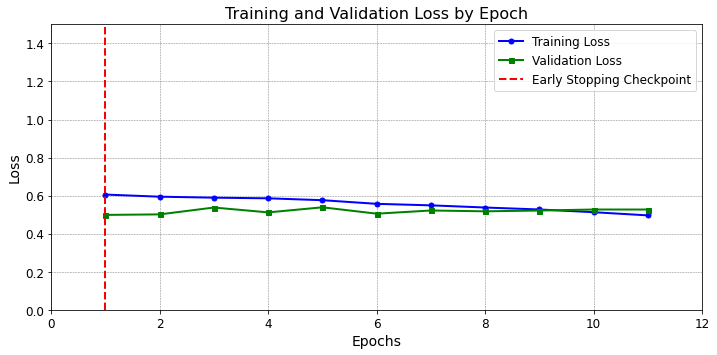

In [89]:
plot_losses(train_losses, valid_losses)

## Testing

### Load Best Model

In [189]:
def load_best_model(checkpoints_dir, based_on='loss', model_class=XRayDenseNet121, num_classes=2):
                    
    checkpoint_files = os.listdir(checkpoints_dir)
    best_file = None
    best_metric = float('inf') if based_on == 'loss' else float('-inf')

    for file in checkpoint_files:
        parts = file.replace('.pt', '').split('_')
        val_loss = float(parts[-1])
        val_auc  = float(parts[4])

        if based_on == 'loss' and val_loss < best_metric:
            best_metric = val_loss
            best_file = file
        elif based_on == 'auc' and val_auc > best_metric:
            best_metric = val_auc
            best_file = file

    if best_file is None:
        raise FileNotFoundError("No checkpoint files found!")

    print(f"Loading best model from {best_file} based on {based_on}...")
        
    best_model = model_class(number_classes)

    checkpoint_path = os.path.join(checkpoints_dir, best_file)
    checkpoint = torch.load(checkpoint_path)
    
    best_model.load_state_dict(checkpoint['model_state_dict'])
    
    return best_model

In [ ]:
checkpoints_dir = './checkpoints/CNN_DenseNet_1/'
best_model = load_best_model(checkpoints_dir, 'auc') # 'auc', 'loss', 'f1'

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
best_model.to(device)

### Test Loop

In [191]:
def test_model(model, dataloader):
    
    model.eval()
    labels = []
    predictions = []
    all_embeddings = []
    
    test_progress_bar = tqdm(dataloader)
    
    for image, label in test_progress_bar:
            
        image = image.to(device).float()
        label = label.to(device).long()

        with torch.no_grad():
            outputs, embeddings = model(image)
            
        embeddings = embeddings.detach().cpu().numpy()
        all_embeddings.extend(embeddings)

        prediction = nn.Softmax(dim=1)(outputs)
        prediction = prediction.detach().cpu().numpy()
        prediction = prediction[:,1]

        label = label.to('cpu').numpy()
        
        labels.extend(label)
        predictions.extend(prediction)
    
    labels = np.array(labels)
    predictions = np.array(predictions)
    
    return labels, predictions, all_embeddings

In [192]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False , collate_fn=collate_test)

In [193]:
test_true_labels , test_prediction_probs , test_embeddings  = test_model(best_model, test_loader)
train_true_labels, train_prediction_probs, train_embeddings = test_model(best_model, train_loader)
valid_true_labels, valid_prediction_probs, valid_embeddings = test_model(best_model, valid_loader)

  0%|          | 0/268 [00:00<?, ?it/s]

  0%|          | 0/1148 [00:00<?, ?it/s]

  0%|          | 0/124 [00:00<?, ?it/s]

### Calibration

In [194]:
def calibrate_probabilities(predicted_probabilities, true_labels):

    predicted_probabilities = np.asarray(predicted_probabilities)
    true_labels = np.asarray(true_labels)

    isotonic_regressor = IsotonicRegression(out_of_bounds='clip')
    isotonic_regressor.fit(predicted_probabilities, true_labels)

    calibrated_probabilities = isotonic_regressor.transform(predicted_probabilities)

    return isotonic_regressor

In [195]:
true_labels_tv = np.concatenate([train_true_labels, valid_true_labels], axis=0)
pred_probs_tv  = np.concatenate([train_prediction_probs,  valid_prediction_probs],  axis=0)

isotonic_regressor = calibrate_probabilities(pred_probs_tv, true_labels_tv)
# test_prediction_probs = isotonic_regressor.transform(test_prediction_probs)

### DenseNet Result

In [197]:
icustay_ids  = train_df['stay_id']
cxr_ids_A = train_df['cxr_image']
cxr_ids_B = train_dataset['cxr_image']
org_label = train_dataset['icu_expire_flag']

train_results_df = pd.DataFrame({'stay_id': icustay_ids,
                                 'cxr_image': cxr_ids_A,
                                 'cxr_image_x': cxr_ids_B,
                                 'icu_expire_flag': org_label,
                                 'True_Label': train_true_labels,
                                 'Predicted_Probability': train_prediction_probs})

In [198]:
icustay_ids  = valid_df['stay_id']
cxr_ids_A = valid_df['cxr_image']
cxr_ids_B = valid_dataset['cxr_image']
org_label = valid_dataset['icu_expire_flag']

valid_results_df = pd.DataFrame({'stay_id': icustay_ids,
                                 'cxr_image': cxr_ids_A,
                                 'cxr_image_x': cxr_ids_B,
                                 'icu_expire_flag': org_label,
                                 'True_Label': valid_true_labels,
                                 'Predicted_Probability': valid_prediction_probs})

In [199]:
icustay_ids  = test_df['stay_id']
cxr_ids_A = test_df['cxr_image']
cxr_ids_B = test_dataset['cxr_image']
org_label = test_dataset['icu_expire_flag']

test_results_df = pd.DataFrame({'stay_id': icustay_ids,
                                'cxr_image': cxr_ids_A,
                                'cxr_image_x': cxr_ids_B,
                                'icu_expire_flag': org_label,
                                'True_Label': test_true_labels,
                                'Predicted_Probability': test_prediction_probs})

In [200]:
train_results_df = train_results_df.merge(train_result, on=['stay_id'], how= 'left')
valid_results_df = valid_results_df.merge(valid_result, on=['stay_id'], how= 'left')
test_results_df  = test_results_df.merge(test_result  , on=['stay_id'], how= 'left')

### Embeddings

In [201]:
encoding_dim = 1024

In [202]:
train_encoded_df = pd.DataFrame(np.array(train_embeddings), columns=[f'embeded_dim{i+1}' for i in range(encoding_dim)])
train_encoded_df['prediction'] = train_prediction_probs 
train_encoded_df['label'] = train_true_labels 

valid_encoded_df = pd.DataFrame(np.array(valid_embeddings), columns=[f'embeded_dim{i+1}' for i in range(encoding_dim)])
valid_encoded_df['prediction'] = valid_prediction_probs 
valid_encoded_df['label'] = valid_true_labels 

test_encoded_df = pd.DataFrame(np.array(test_embeddings), columns=[f'embeded_dim{i+1}' for i in range(encoding_dim)])
test_encoded_df['prediction'] = test_prediction_probs 
test_encoded_df['label'] = test_true_labels 

In [203]:
train_results = pd.concat([train_results_df, train_encoded_df], axis=1)
valid_results = pd.concat([valid_results_df, valid_encoded_df], axis=1)
test_results  = pd.concat([test_results_df , test_encoded_df] , axis=1)

In [204]:
train_results['lbl_matching'] = train_results.apply(lambda x: x.icu_expire_flag_x == x.icu_expire_flag_y == x.True_Label == x.label, axis = 1)
valid_results['lbl_matching'] = valid_results.apply(lambda x: x.icu_expire_flag_x == x.icu_expire_flag_y == x.True_Label == x.label, axis = 1)
test_results['lbl_matching']  = test_results.apply(lambda  x: x.icu_expire_flag_x == x.icu_expire_flag_y == x.True_Label == x.label, axis = 1)

train_results['cxr_matching'] = train_results.apply(lambda x: x.cxr_image == x.cxr_image_x, axis = 1)
valid_results['cxr_matching'] = valid_results.apply(lambda x: x.cxr_image == x.cxr_image_x, axis = 1)
test_results['cxr_matching']  = test_results.apply(lambda  x: x.cxr_image == x.cxr_image_x, axis = 1)

print(train_results[train_results.lbl_matching == False].shape)
print(valid_results[valid_results.lbl_matching == False].shape)
print(test_results[test_results.lbl_matching   == False].shape)

print(train_results[train_results.cxr_matching == False].shape)
print(valid_results[valid_results.cxr_matching == False].shape)
print(test_results[test_results.cxr_matching   == False].shape)

(0, 1039)
(0, 1039)
(0, 1039)
(0, 1039)
(0, 1039)
(0, 1039)


### Filter Images of First 24 Hours

In [205]:
test_results_df = test_results_df[test_results_df.cxr_image.isin(image_ids_24h)]

### Results

In [206]:
keep_columns = ['stay_id', 'cxr_image', 'True_Label', 'ICU_FLAG', 'Predicted_Probability', 'age', 'gender', 'race']

images_result_df = test_results_df[['stay_id', 'cxr_image', 'True_Label', 'Predicted_Probability']].groupby(['stay_id', 'cxr_image']).max().reset_index()
idx = test_results_df.groupby('stay_id')['Predicted_Probability'].idxmax()
patients_result_df = test_results_df.loc[idx][keep_columns]

In [207]:
patients_result_df.head(3)

In [208]:
print(images_result_df.shape)
print(patients_result_df.shape)
print(patients_result_df.stay_id.nunique())
print(patients_result_df.cxr_image.nunique())

(2507, 4)
(1810, 8)
1810
1810


In [209]:
cxr_true_labels = images_result_df['True_Label']
cxr_pred_probs  = images_result_df['Predicted_Probability']

patient_true_labels = patients_result_df['True_Label']
patient_pred_probs  = patients_result_df['Predicted_Probability']

### ROC

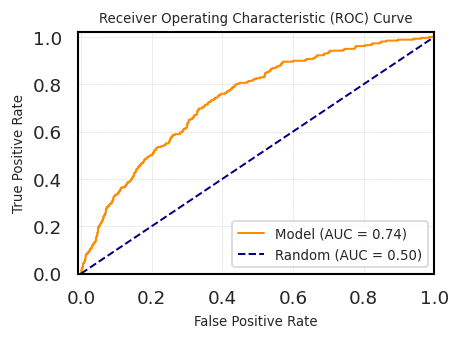

In [210]:
ROC_curve(images_result_df.True_Label, images_result_df.Predicted_Probability)

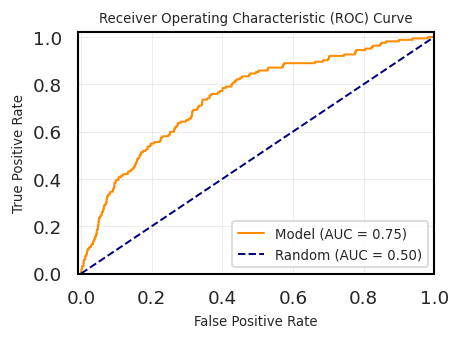

In [211]:
ROC_curve(patients_result_df.True_Label, patients_result_df.Predicted_Probability)

### Precision - Recall

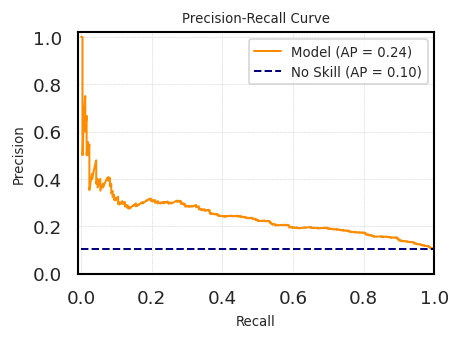

In [212]:
PRC_REC_curve(images_result_df.True_Label, images_result_df.Predicted_Probability)

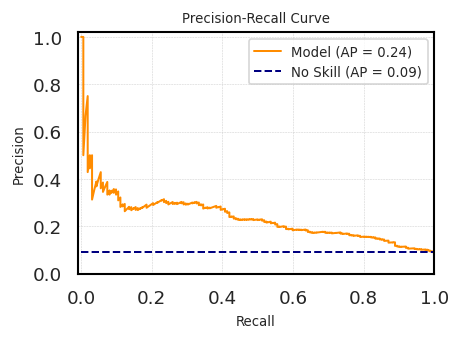

In [213]:
PRC_REC_curve(patients_result_df.True_Label, patients_result_df.Predicted_Probability)

### Set Decision Threshold

In [216]:
decision_recall = 0.8

In [217]:
cxr_predicted_label, cxr_decision_threshold = Prediction_Labels_Thresholding(cxr_true_labels, 
                                                                             cxr_pred_probs, 
                                                                             decision_recall)

images_result_df['Predicted_Label'] = cxr_predicted_label

Decision Threshold is:  0.27


In [218]:
patient_predicted_label, patient_decision_threshold = Prediction_Labels_Thresholding(patient_true_labels, 
                                                                                     patient_pred_probs, 
                                                                                     decision_recall)

patients_result_df['Predicted_Label'] = patient_predicted_label

Decision Threshold is:  0.28


### Confusion Matrix

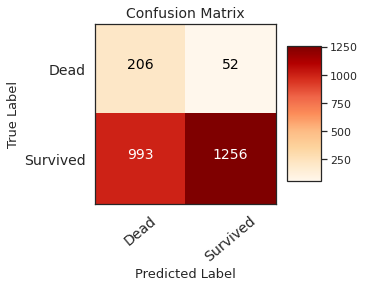

In [219]:
Confusion_Matrix(cxr_true_labels, cxr_predicted_label, classes = ['Dead', 'Survived'])

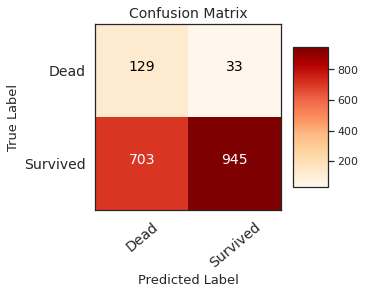

In [220]:
Confusion_Matrix(patient_true_labels, patient_predicted_label, classes = ['Dead', 'Survived'])

### Performance Metrics

In [221]:
Performance_Metrics(cxr_true_labels, cxr_predicted_label, cxr_pred_probs)

ACC =  0.58
PRC =  0.17
REC =  0.8
F1M =  0.28
PPV =  0.17
NPV =  0.96
SEN =  0.8
SPE =  0.56
FPR =  0.44
FNR =  0.2
FDR =  0.83
AUC =  0.74
AP  =  0.24
MCC =  0.22


In [222]:
Performance_Metrics(patient_true_labels, patient_predicted_label, patient_pred_probs)

ACC =  0.59
PRC =  0.16
REC =  0.8
F1M =  0.26
PPV =  0.16
NPV =  0.97
SEN =  0.8
SPE =  0.57
FPR =  0.43
FNR =  0.2
FDR =  0.84
AUC =  0.75
AP  =  0.24
MCC =  0.21


### Distribution of Prediction Probabilities

In [223]:
df_prediction_alive = patients_result_df[patients_result_df['ICU_FLAG'] == 'Survived']
df_prediction_dead  = patients_result_df[patients_result_df['ICU_FLAG'] == 'Dead']

### Alive Patients

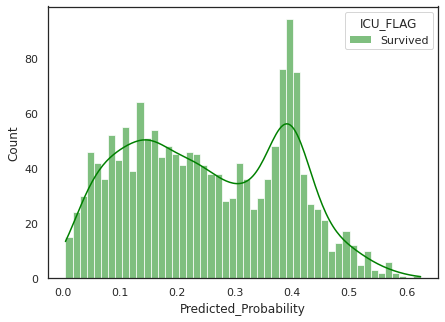

In [224]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_alive, x='Predicted_Probability', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['green'])
plt.show()

### Dead Patients

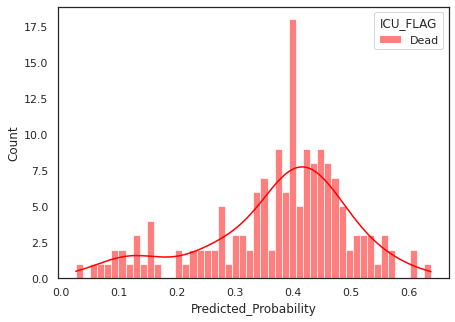

In [225]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_dead, x='Predicted_Probability', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['red'])
plt.show()

ROC AUC:  0.75
PR  AUC:  0.24
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

    Negative       0.97      0.57      0.72      1648
    Positive       0.16      0.80      0.26       162

    accuracy                           0.59      1810
   macro avg       0.56      0.68      0.49      1810
weighted avg       0.89      0.59      0.68      1810

None


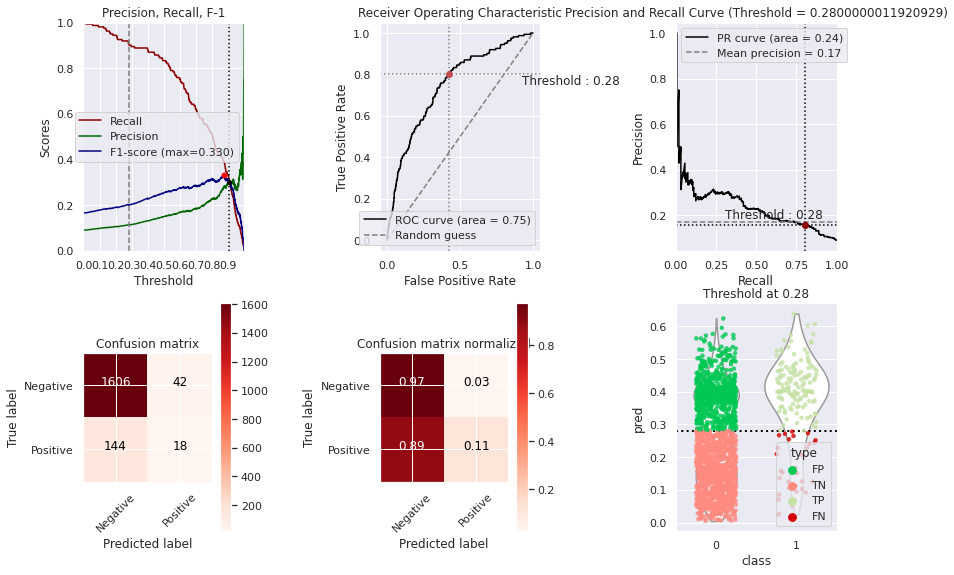

In [226]:
Binary_Classification_Performance(patient_true_labels, patient_pred_probs, patient_decision_threshold)

### Save Result

In [227]:
train_results = train_results.drop(columns= ['cxr_image_x', 'icu_expire_flag_x', 'label', 'prediction', 'lbl_matching', 'cxr_matching'], axis=1)
valid_results = valid_results.drop(columns= ['cxr_image_x', 'icu_expire_flag_x', 'label', 'prediction', 'lbl_matching', 'cxr_matching'], axis=1)
test_results  = test_results.drop(columns=  ['cxr_image_x', 'icu_expire_flag_x', 'label', 'prediction', 'lbl_matching', 'cxr_matching'], axis=1)

train_results = train_results.rename(columns={"icu_expire_flag_y": "icu_expire_flag"})
valid_results = valid_results.rename(columns={"icu_expire_flag_y": "icu_expire_flag"})
test_results  = test_results.rename(columns={"icu_expire_flag_y" : "icu_expire_flag"})

In [229]:
concat_text = [train_results, valid_results, test_results]
cxr_image_representation = pd.concat(concat_text)

cxr_image_representation.head(2)

In [230]:
# cxr_image_representation.to_csv(path_out + "cxr_densnet_representation.csv", index=False)
# patients_result_df.to_csv("./Results/CXR_Max_Result.csv", index=False)

### Bias & Fairness

In [231]:
patients_result_df.head(3)

### Read Race Dictionary

In [232]:
with open(race_path + 'race_dictionary.pkl', 'rb') as f:
    race_dictionary = pickle.load(f)

In [233]:
general_ethnicity_mapping = {
    
    'WHITE': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - BRAZILIAN': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'WHITE - EASTERN EUROPEAN': 'White',
    'PORTUGUESE': 'White',
    
    'UNKNOWN': 'Unknown',
    'UNABLE TO OBTAIN': 'Unknown',
    'PATIENT DECLINED TO ANSWER': 'Unknown',
    
    'OTHER': 'Other',
    'MIDDLE EASTERN': 'Other',
    'MULTIPLE RACE/ETHNICITY': 'Other',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'Other',
    
    'ASIAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - SOUTH EAST ASIAN': 'Asian',
    'ASIAN - KOREAN': 'Asian',
    'ASIAN - ASIAN INDIAN': 'Asian',
    
    'AMERICAN INDIAN/ALASKA NATIVE': 'Native American',
    
    'BLACK/AFRICAN': 'Black/African American',
    'BLACK/CAPE VERDEAN': 'Black/African American',
    'BLACK/AFRICAN AMERICAN': 'Black/African American',
    'BLACK/CARIBBEAN ISLAND': 'Black/African American',
    
    'SOUTH AMERICAN': 'Hispanic/Latino',
    'HISPANIC OR LATINO': 'Hispanic/Latino',
    'HISPANIC/LATINO - CUBAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - MEXICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - HONDURAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - COLUMBIAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - GUATEMALAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'Hispanic/Latino'}

In [234]:
def replace_ethnicity_with_names(df, ethnicity_dict):
    
    inv_ethnicity_dict = {v: k for k, v in ethnicity_dict.items()}
    df['race'] = df['race'].map(inv_ethnicity_dict)
    
    return df

In [235]:
def categorize_ethnicity(df, new_mapping):
    
    df['race'] = df['race'].map(new_mapping)
    
    return df

In [236]:
demog_col = ['stay_id', 'gender', 'age', 'race']
df_demog = patients_result_df[demog_col].copy()

df_demog = replace_ethnicity_with_names(df_demog, race_dictionary)
df_demog = categorize_ethnicity(df_demog, general_ethnicity_mapping)

df_demog = df_demog.drop_duplicates().reset_index(drop=True)
df_demog.loc[df_demog.gender == 1.0, 'gender'] = 'Male'
df_demog.loc[df_demog.gender == 2.0, 'gender'] = 'Female'

bins = [-np.inf, 35, 50, 60, 75, np.inf]
labels = ['Under 35', '36-50', '51-60', '61-75', 'Over 76']
df_demog['agegroup'] = pd.cut(df_demog['age'], bins=bins, labels=labels, right=False)
df_demog = df_demog.drop(columns= 'age')

In [237]:
df_demog.head(3)

### CNN Result Frame

In [238]:
LLM_df_bias = patients_result_df[['stay_id', 'Predicted_Label', 'True_Label']]
LLM_df_bias = pd.merge(LLM_df_bias, df_demog, on=['stay_id'], how='left')

LLM_df_bias.rename(columns={'gender': 'sex',
                            'race' : 'ethnic',
                            'stay_id': 'entity_id',
                            'Predicted_Label': 'score', 
                            'True_Label': 'label_value'}, inplace=True)

LLM_df_bias['sex']  = LLM_df_bias.sex.astype(str)
LLM_df_bias['score'] = LLM_df_bias.score.astype(int)
LLM_df_bias['ethnic'] = LLM_df_bias.ethnic.astype(str)
LLM_df_bias['agegroup'] = LLM_df_bias.agegroup.astype(str)
LLM_df_bias.head(3)

In [239]:
g = Group()

LLMtab, _ = g.get_crosstabs(LLM_df_bias, attr_cols=['sex', 'agegroup', 'ethnic'])
LLMtab['model_id'] = 'LLM'
LLMtab.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev
0,LLM,binary 0/1,832,sex,Female,0.541716,0.876712,0.510283,0.022167,0.856180,0.489717,0.123288,0.977833,0.143820,445,406,0.534856,0.522914,381,9,397,64,73,778,851,1810,0.085781
1,LLM,binary 0/1,832,sex,Male,0.639208,0.730337,0.629885,0.041958,0.832041,0.370115,0.269663,0.958042,0.167959,387,572,0.465144,0.403545,322,24,548,65,89,870,959,1810,0.092805
2,LLM,binary 0/1,832,agegroup,36-50,0.696429,0.909091,0.681529,0.009259,0.833333,0.318471,0.090909,0.990741,0.166667,60,108,0.072115,0.357143,50,1,107,10,11,157,168,1810,0.065476


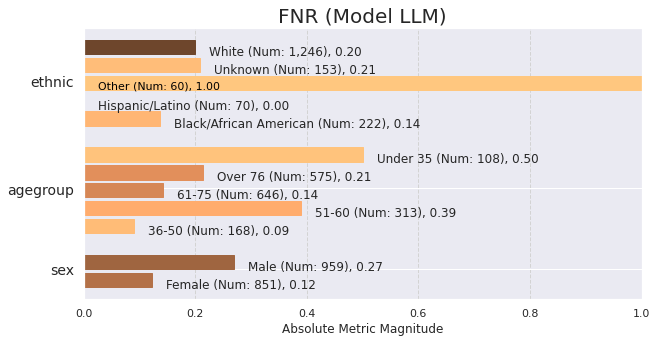

In [240]:
aqp = Plot()

a = aqp.plot_group_metric(LLMtab, 'fnr', min_group_size=0.01)

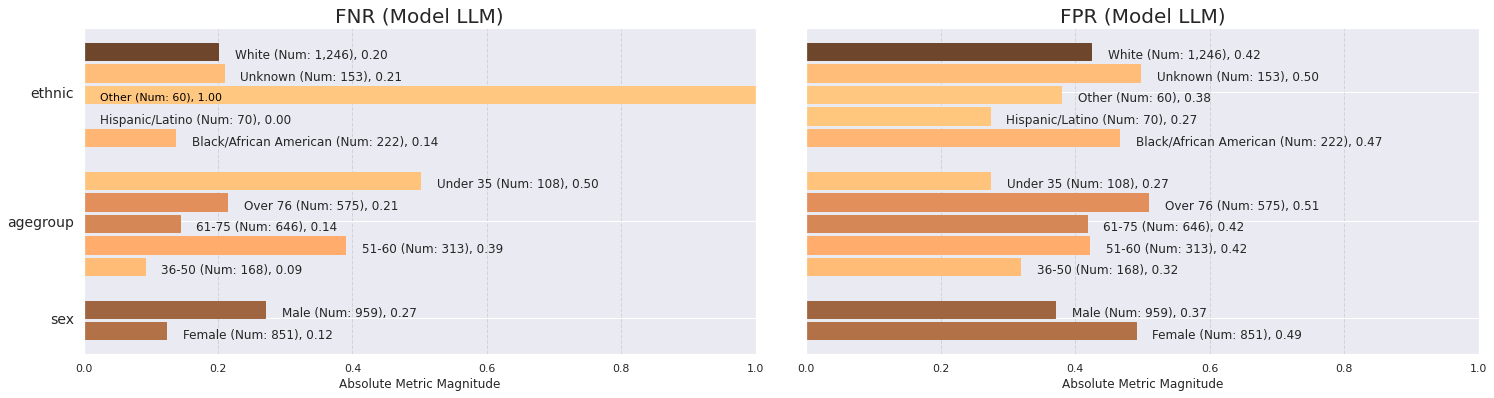

<Figure size 432x288 with 0 Axes>

In [241]:
a = aqp.plot_group_metric_all(LLMtab, metrics=['fnr','fpr'], ncols=2, min_group_size=0.01)

In [242]:
b = Bias()

sex_ref = 'Male' 
age_ref = '51-60'
ethnic_ref = 'White'

In [243]:
bdf = b.get_disparity_predefined_groups(LLMtab, original_df=LLM_df_bias, alpha=0.05, mask_significance=True,
                                        ref_groups_dict={'ethnic':ethnic_ref,'sex':sex_ref,'agegroup':age_ref})
majority_bdf = b.get_disparity_major_group(LLMtab, original_df=LLM_df_bias, mask_significance=True)
min_metric_bdf = b.get_disparity_min_metric(df=LLMtab, original_df=LLM_df_bias)
bdf.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,ppr_disparity,pprev_disparity,precision_disparity,fdr_disparity,for_disparity,fpr_disparity,fnr_disparity,tpr_disparity,tnr_disparity,npv_disparity,ppr_ref_group_value,pprev_ref_group_value,precision_ref_group_value,fdr_ref_group_value,for_ref_group_value,fpr_ref_group_value,fnr_ref_group_value,tpr_ref_group_value,tnr_ref_group_value,npv_ref_group_value
0,LLM,binary 0/1,832,sex,Female,0.541716,0.876712,0.510283,0.022167,0.856180,0.489717,0.123288,0.977833,0.143820,445,406,0.534856,0.522914,381,9,397,64,73,778,851,1810,0.085781,1.149871,1.295800,0.856283,1.029011,0.528325,1.323149,0.457192,1.200421,0.810120,1.020657,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
1,LLM,binary 0/1,832,sex,Male,0.639208,0.730337,0.629885,0.041958,0.832041,0.370115,0.269663,0.958042,0.167959,387,572,0.465144,0.403545,322,24,548,65,89,870,959,1810,0.092805,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
2,LLM,binary 0/1,832,agegroup,36-50,0.696429,0.909091,0.681529,0.009259,0.833333,0.318471,0.090909,0.990741,0.166667,60,108,0.072115,0.357143,50,1,107,10,11,157,168,1810,0.065476,0.444444,0.828042,2.045455,0.907258,0.235450,0.757654,0.233766,1.487603,1.175737,1.031297,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60


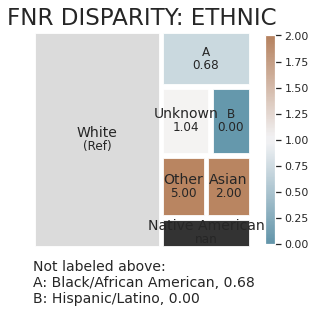

In [244]:
aqp.plot_disparity(majority_bdf, group_metric='fnr_disparity', attribute_name='ethnic', significance_alpha=0.05)

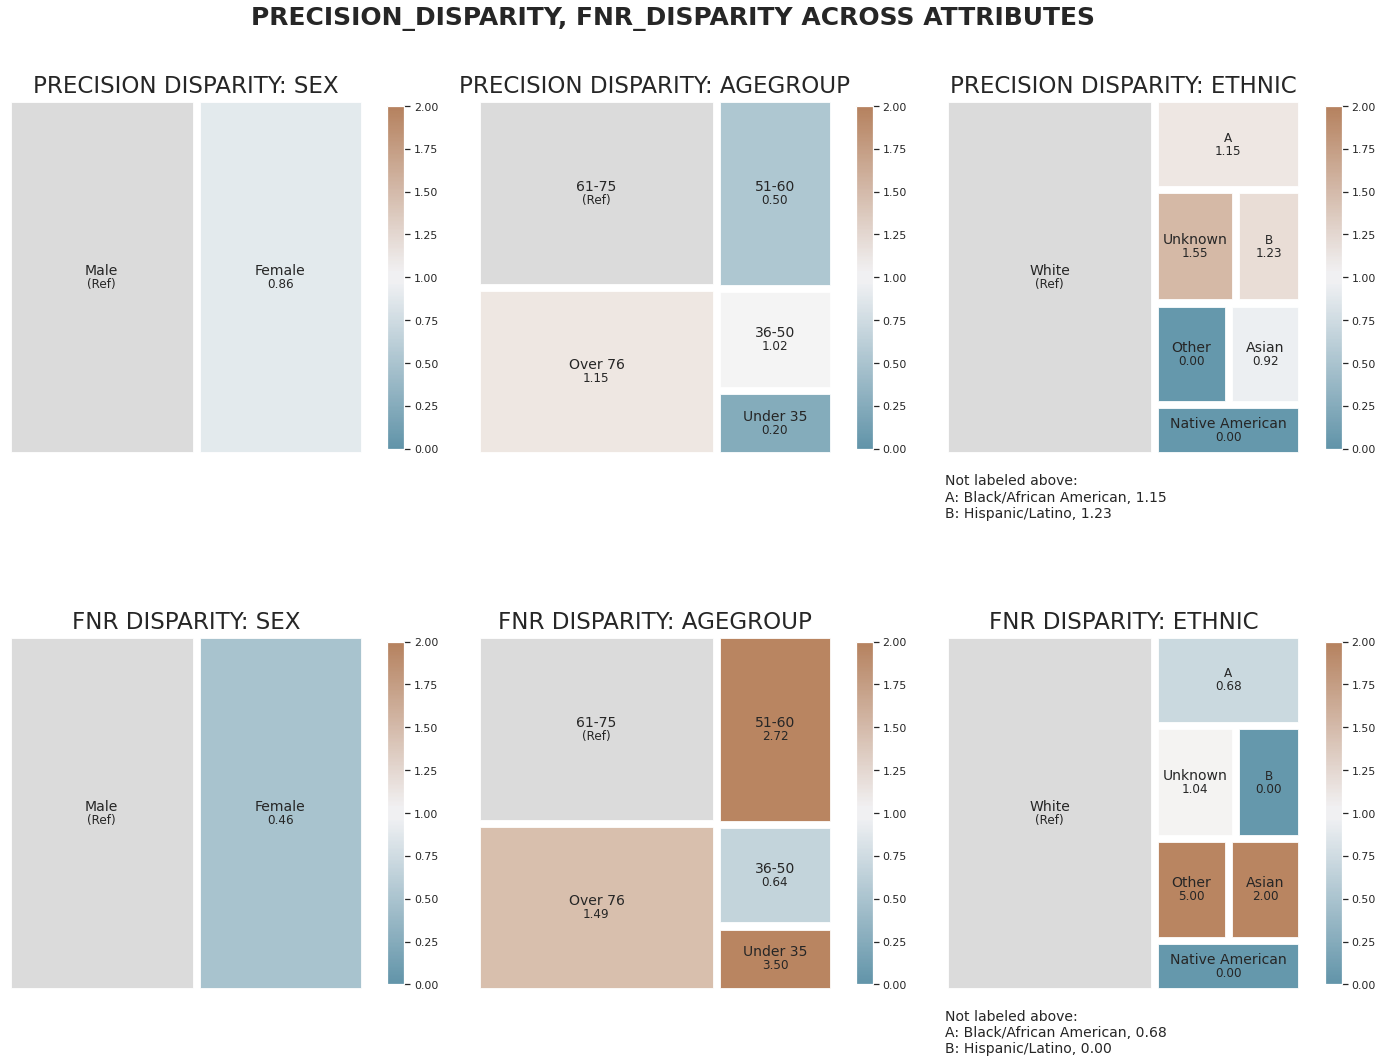

In [245]:
a = aqp.plot_disparity_all(majority_bdf, metrics=['precision_disparity', 'fnr_disparity'], significance_alpha=0.05)

In [246]:
f = Fairness()

fdf = f.get_group_value_fairness(bdf)
gaf = f.get_group_attribute_fairness(fdf)
fdf.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,ppr_disparity,pprev_disparity,precision_disparity,fdr_disparity,for_disparity,fpr_disparity,fnr_disparity,tpr_disparity,tnr_disparity,npv_disparity,ppr_ref_group_value,pprev_ref_group_value,precision_ref_group_value,fdr_ref_group_value,for_ref_group_value,fpr_ref_group_value,fnr_ref_group_value,tpr_ref_group_value,tnr_ref_group_value,npv_ref_group_value,Statistical Parity,Impact Parity,FDR Parity,FPR Parity,FOR Parity,FNR Parity,TPR Parity,TNR Parity,NPV Parity,Precision Parity,TypeI Parity,TypeII Parity,Equalized Odds,Unsupervised Fairness,Supervised Fairness
0,LLM,binary 0/1,832,sex,Female,0.541716,0.876712,0.510283,0.022167,0.856180,0.489717,0.123288,0.977833,0.143820,445,406,0.534856,0.522914,381,9,397,64,73,778,851,1810,0.085781,1.149871,1.295800,0.856283,1.029011,0.528325,1.323149,0.457192,1.200421,0.810120,1.020657,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,True,False,True,False,False,False,True,True,True,True,False,False,False,False,False
1,LLM,binary 0/1,832,sex,Male,0.639208,0.730337,0.629885,0.041958,0.832041,0.370115,0.269663,0.958042,0.167959,387,572,0.465144,0.403545,322,24,548,65,89,870,959,1810,0.092805,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,LLM,binary 0/1,832,agegroup,36-50,0.696429,0.909091,0.681529,0.009259,0.833333,0.318471,0.090909,0.990741,0.166667,60,108,0.072115,0.357143,50,1,107,10,11,157,168,1810,0.065476,0.444444,0.828042,2.045455,0.907258,0.235450,0.757654,0.233766,1.487603,1.175737,1.031297,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60,51-60,False,True,True,False,False,False,False,True,True,False,False,False,False,False,False


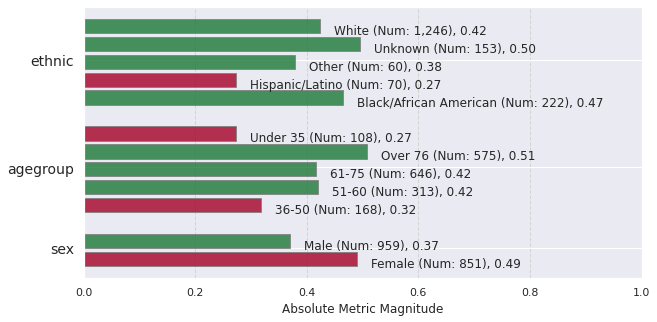

In [247]:
a = aqp.plot_fairness_group(fdf, group_metric='fpr', min_group_size=0.01)

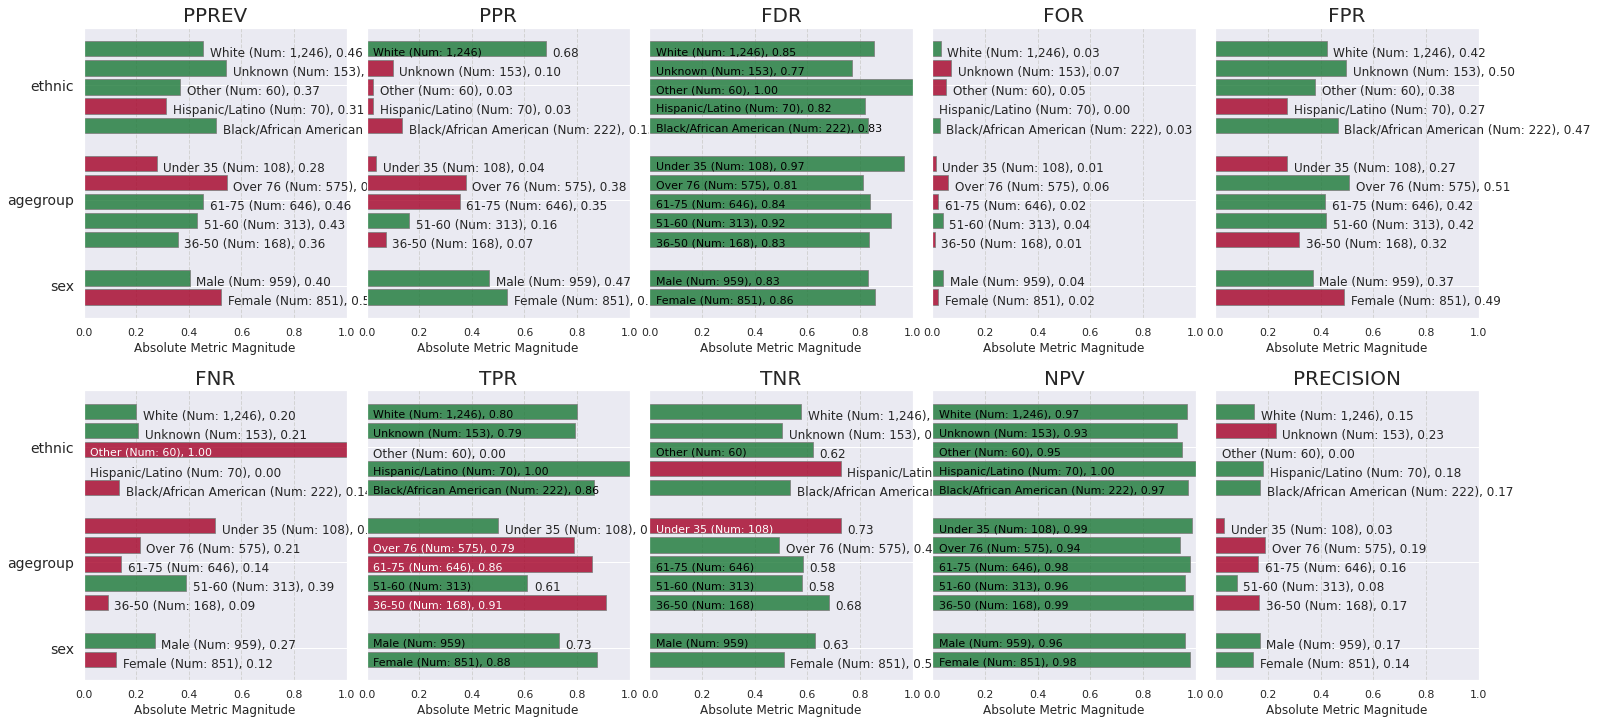

<Figure size 432x288 with 0 Axes>

In [248]:
a = aqp.plot_fairness_group_all(fdf, ncols=5, metrics = "all", min_group_size=0.01)

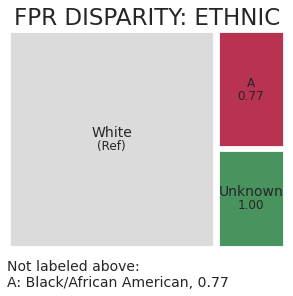

In [274]:
a = aqp.plot_fairness_disparity(fdf, group_metric='fpr', attribute_name='ethnic', min_group_size=0.02, significance_alpha=0.05)

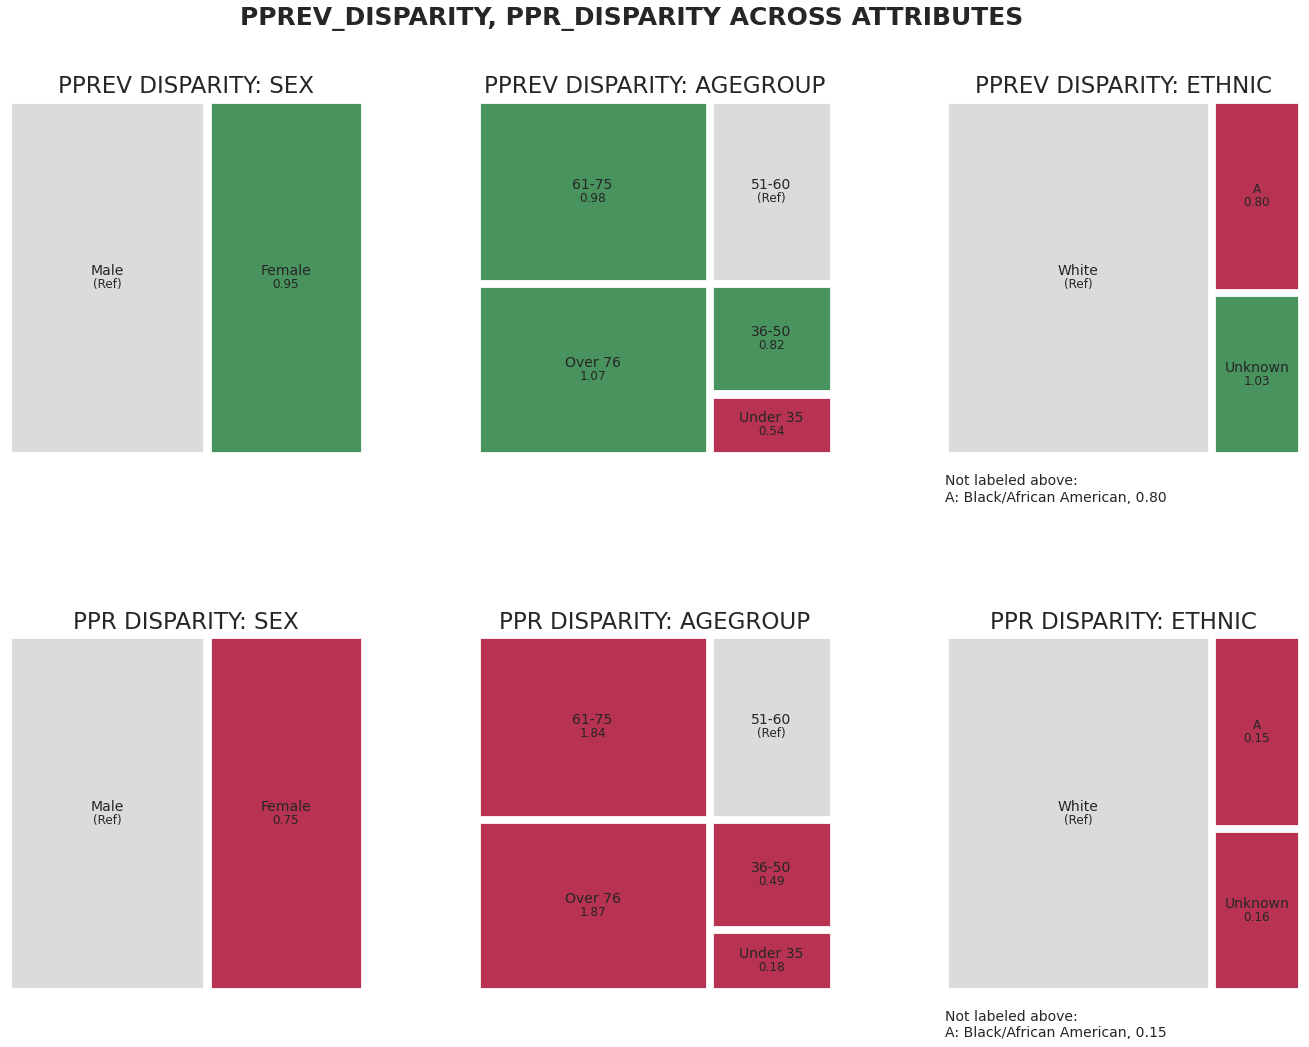

In [275]:
a = aqp.plot_fairness_disparity_all(fdf, metrics=['pprev_disparity', 'ppr_disparity'],  min_group_size=0.02, significance_alpha=0.05)

### Check Model Output

In [120]:
batch_size = 1

test_dataloader = DataLoader(test_dataset , batch_size=batch_size, collate_fn=collate_test)

test_dataloader_iter = iter(test_dataloader)

In [121]:
batch = next(test_dataloader_iter)

images = batch[0]
labels = batch[1]

In [122]:
images = images.to(device).float()
labels = labels.to(device).long()

with torch.no_grad():
    outputs, features = best_model(images)
    
prediction = nn.Softmax(dim=1)(outputs)
print(prediction)
print(batch[1])

tensor([[0.8124, 0.1876]], device='cuda:0')
tensor([0.])


## Interpretation

In [154]:
batch_size = 1

test_dataloader = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, collate_fn=collate_test)

test_dataloader_iter = iter(test_dataloader)

In [123]:
batch = next(test_dataloader_iter)

image = batch[0]
label = batch[1]

image = image.to(device).float()
label = label.to(device)
label = int(label.item())

### Choose Image

In [107]:
target_result = test_results_df[test_results_df.True_Label == 1].sort_values(by='Predicted_Probability', ascending=False).reset_index(drop=True)
target_result = target_result.drop(columns=['cxr_image_x', 'icu_expire_flag_y'])

In [109]:
image_path = 'DICOM ID'   # choose a dicom_id from target_result above


In [110]:
label = test_df[test_df.cxr_image == image_path]['icu_expire_flag'].values[0]
image_path = test_df[test_df.cxr_image == image_path]['path'].values[0]

In [111]:
image = load_and_transform_image(image_path)
image = test_transforms(image)
image = image.unsqueeze(0)

image = image.to(device)
label = torch.tensor(label)
label = label.to(device)
label = int(label.item())

### Grad_CAM (1)

In [115]:
class GradCAM_1:
    
    def __init__(self, model, target_layer):
        
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.hook_layers()
    
    def hook_layers(self):
        
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]
        
        def forward_hook(module, input, output):
            self.activations = output
        
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)
    
    def generate_cam(self, input_image, target_class=None):
        
        self.model.eval()
        self.model.zero_grad()
        
        logits, _ = self.model(input_image)
        
        if target_class is None:
            target_class = torch.argmax(logits)
        
        class_score = logits[:, target_class]
        class_score.backward()
        
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        self.activations *= pooled_gradients.unsqueeze(-1).unsqueeze(-1)
        
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = torch.clamp(heatmap, min=0)
        
        heatmap /= (torch.max(heatmap) + 1e-8)
        
        prediction = nn.Softmax(dim=1)(logits)
        prediction = prediction.detach().cpu().numpy()
        
        return heatmap.cpu().detach().numpy(), prediction
    
    
def visualize_grad_cam(image, heatmap, alpha=0.5):

    image = image.squeeze().permute(1, 2, 0).cpu().numpy()
    image = (image - image.min()) / (image.max() - image.min())

    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.float32(heatmap)

    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = np.float32(heatmap_colored) / np.max(heatmap_colored)

    cam_image = alpha * heatmap_colored + image
    cam_image = cam_image / np.max(cam_image)

    fig, ax = plt.subplots(1, 3, figsize=(16, 12))
    ax[0].imshow(image)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    ax[1].imshow(heatmap_colored)
    ax[1].set_title('Grad-CAM Heatmap')
    ax[1].axis('off')

    ax[2].imshow(cam_image)
    ax[2].set_title('Overlayed Image')
    ax[2].axis('off')

    plt.show()

In [116]:
target_layer = best_model.densenet121.features.denseblock4.denselayer16.conv1
# target_layer = best_model.densenet121.features[-1]

In [117]:
grad_cam = GradCAM_1(best_model, target_layer)
heatmap, score = grad_cam.generate_cam(image, target_class=label)
visualize_grad_cam(image, heatmap)
print(f"Predicted probability: {score}")

<Figure size 1152x864 with 3 Axes>

Predicted probability: [[0.15727149 0.8427285 ]]


### Grad_CAM (2)

In [118]:
class GradCAM_2:
    
    def __init__(self, model, target_layer):
        
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.hook_layers()

    def hook_layers(self):
        
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]
        
        def forward_hook(module, input, output):
            self.activations = output
        
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)
    
    def generate_cam(self, input_image, target_class=None):
        
        self.model.eval()
        self.model.zero_grad()
        
        logits, _ = self.model(input_image)
        
        if target_class is None:
            target_class = torch.argmax(logits)
        
        class_score = logits[:, target_class]
        class_score.backward()
        
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        self.activations *= pooled_gradients.view(1, -1, 1, 1)
        
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = torch.clamp(heatmap, min=0)
        heatmap /= torch.max(heatmap)
        heatmap = heatmap.cpu().detach().numpy()
        heatmap = cv2.resize(heatmap, (input_image.shape[3], input_image.shape[2]))
        
        prediction = nn.Softmax(dim=1)(logits)
        prediction = prediction.detach().cpu().numpy()

        return heatmap, prediction

    def visualize_heatmap(self, input_image, heatmap, alpha=0.5):
        
        image = input_image.squeeze().permute(1, 2, 0).cpu().numpy()
        image = (image - image.min()) / (image.max() - image.min()) * 255  # Normalize image
        
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        cam = alpha * heatmap + (1 - alpha) * image
        cam = np.uint8(cam / np.max(cam) * 255)
        
        plt.figure(figsize=(14, 8))
        plt.imshow(cam)
        plt.axis('off')
        plt.show()

    def __call__(self, input_image, target_class=None):
        
        heatmap, prob = self.generate_cam(input_image, target_class)
        self.visualize_heatmap(input_image, heatmap)
        
        return heatmap, prob

In [119]:
target_layer = best_model.densenet121.features.denseblock4.denselayer16.conv2
# target_layer = best_model.densenet121.features[-1]

In [ ]:
grad_cam = GradCAM_2(best_model, target_layer)
heatmap, prob = grad_cam(image, target_class=label)
print(f"Predicted probability: {prob}")

### Grad_CAM (3)

In [121]:
# target_layer = [best_model.densenet121.features.denseblock4.denselayer16.conv1]
target_layer = [best_model.densenet121.features[-1]]
target = [ClassifierOutputTarget(label)]

In [122]:
grad_cam = GradCAM(model=best_model, target_layers=target_layer)

In [123]:
# Pass aug_smooth=True, eigen_smooth=True for Smoothing.

grayscale_cam = grad_cam(input_tensor=image, targets=target, aug_smooth=True, eigen_smooth=True)

In [124]:
grayscale_cam = grayscale_cam[0, :]

orig_image = np.float32(image.squeeze().permute(1, 2, 0).cpu().numpy())
orig_image = (orig_image - orig_image.min()) / (orig_image.max() - orig_image.min())

cam_image = show_cam_on_image(orig_image, grayscale_cam, use_rgb=True)

grayscale_cam = np.uint8(255 * grayscale_cam)
grayscale_cam = cv2.merge([grayscale_cam, grayscale_cam, grayscale_cam])

In [125]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(cam_image)

ax.set(yticklabels=[]) 
ax.set(xticklabels=[]) 
ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, labelbottom=False) 

<Figure size 720x504 with 1 Axes>

In [126]:
visualize_grad_cam(image, grayscale_cam, alpha=0.5)

<Figure size 1152x864 with 3 Axes>